In [2]:
import json
import os
import logging
import numpy as np
import requests
from PIL import Image
import scipy.stats
import matplotlib.pyplot as plt
import sys
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)

# check环境
print(sys.executable)
print(sys.version)

/nfs_beijing/kubeflow-user/yujie/.conda/envs/icey/bin/python
3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]


In [56]:
data = pd.read_csv('../data/data_expert_r1_dms.csv',
                  index_col=0)
data['mut1'] = data['pdb_mutation'].apply(lambda x: sorted([a[2:-1] for a in x.split(',')])[0]  if x != '' else '0')
data['mut2'] = data['pdb_mutation'].apply(lambda x: sorted([a[2:-1] for a in x.split(',')])[1]
                                                        if x != '' and len(sorted([int(a[2:-1]) for a in x.split(',')])) > 1 else '0'
                                         )
print(data.columns)

Index(['unique_id', 'label', 'wt_aa_seq', 'mt_aa_seq', 'pdb_mutation',
       'aa_schema', 'mut_num', 'attn_region', 'split', 'mt_label', 'wt_label',
       'stability', 'structure_naturalness', 'sequence_naturalness',
       'activity_v0(zero-shot)', 'mut1', 'mut2'],
      dtype='object')


## pred vs True Label

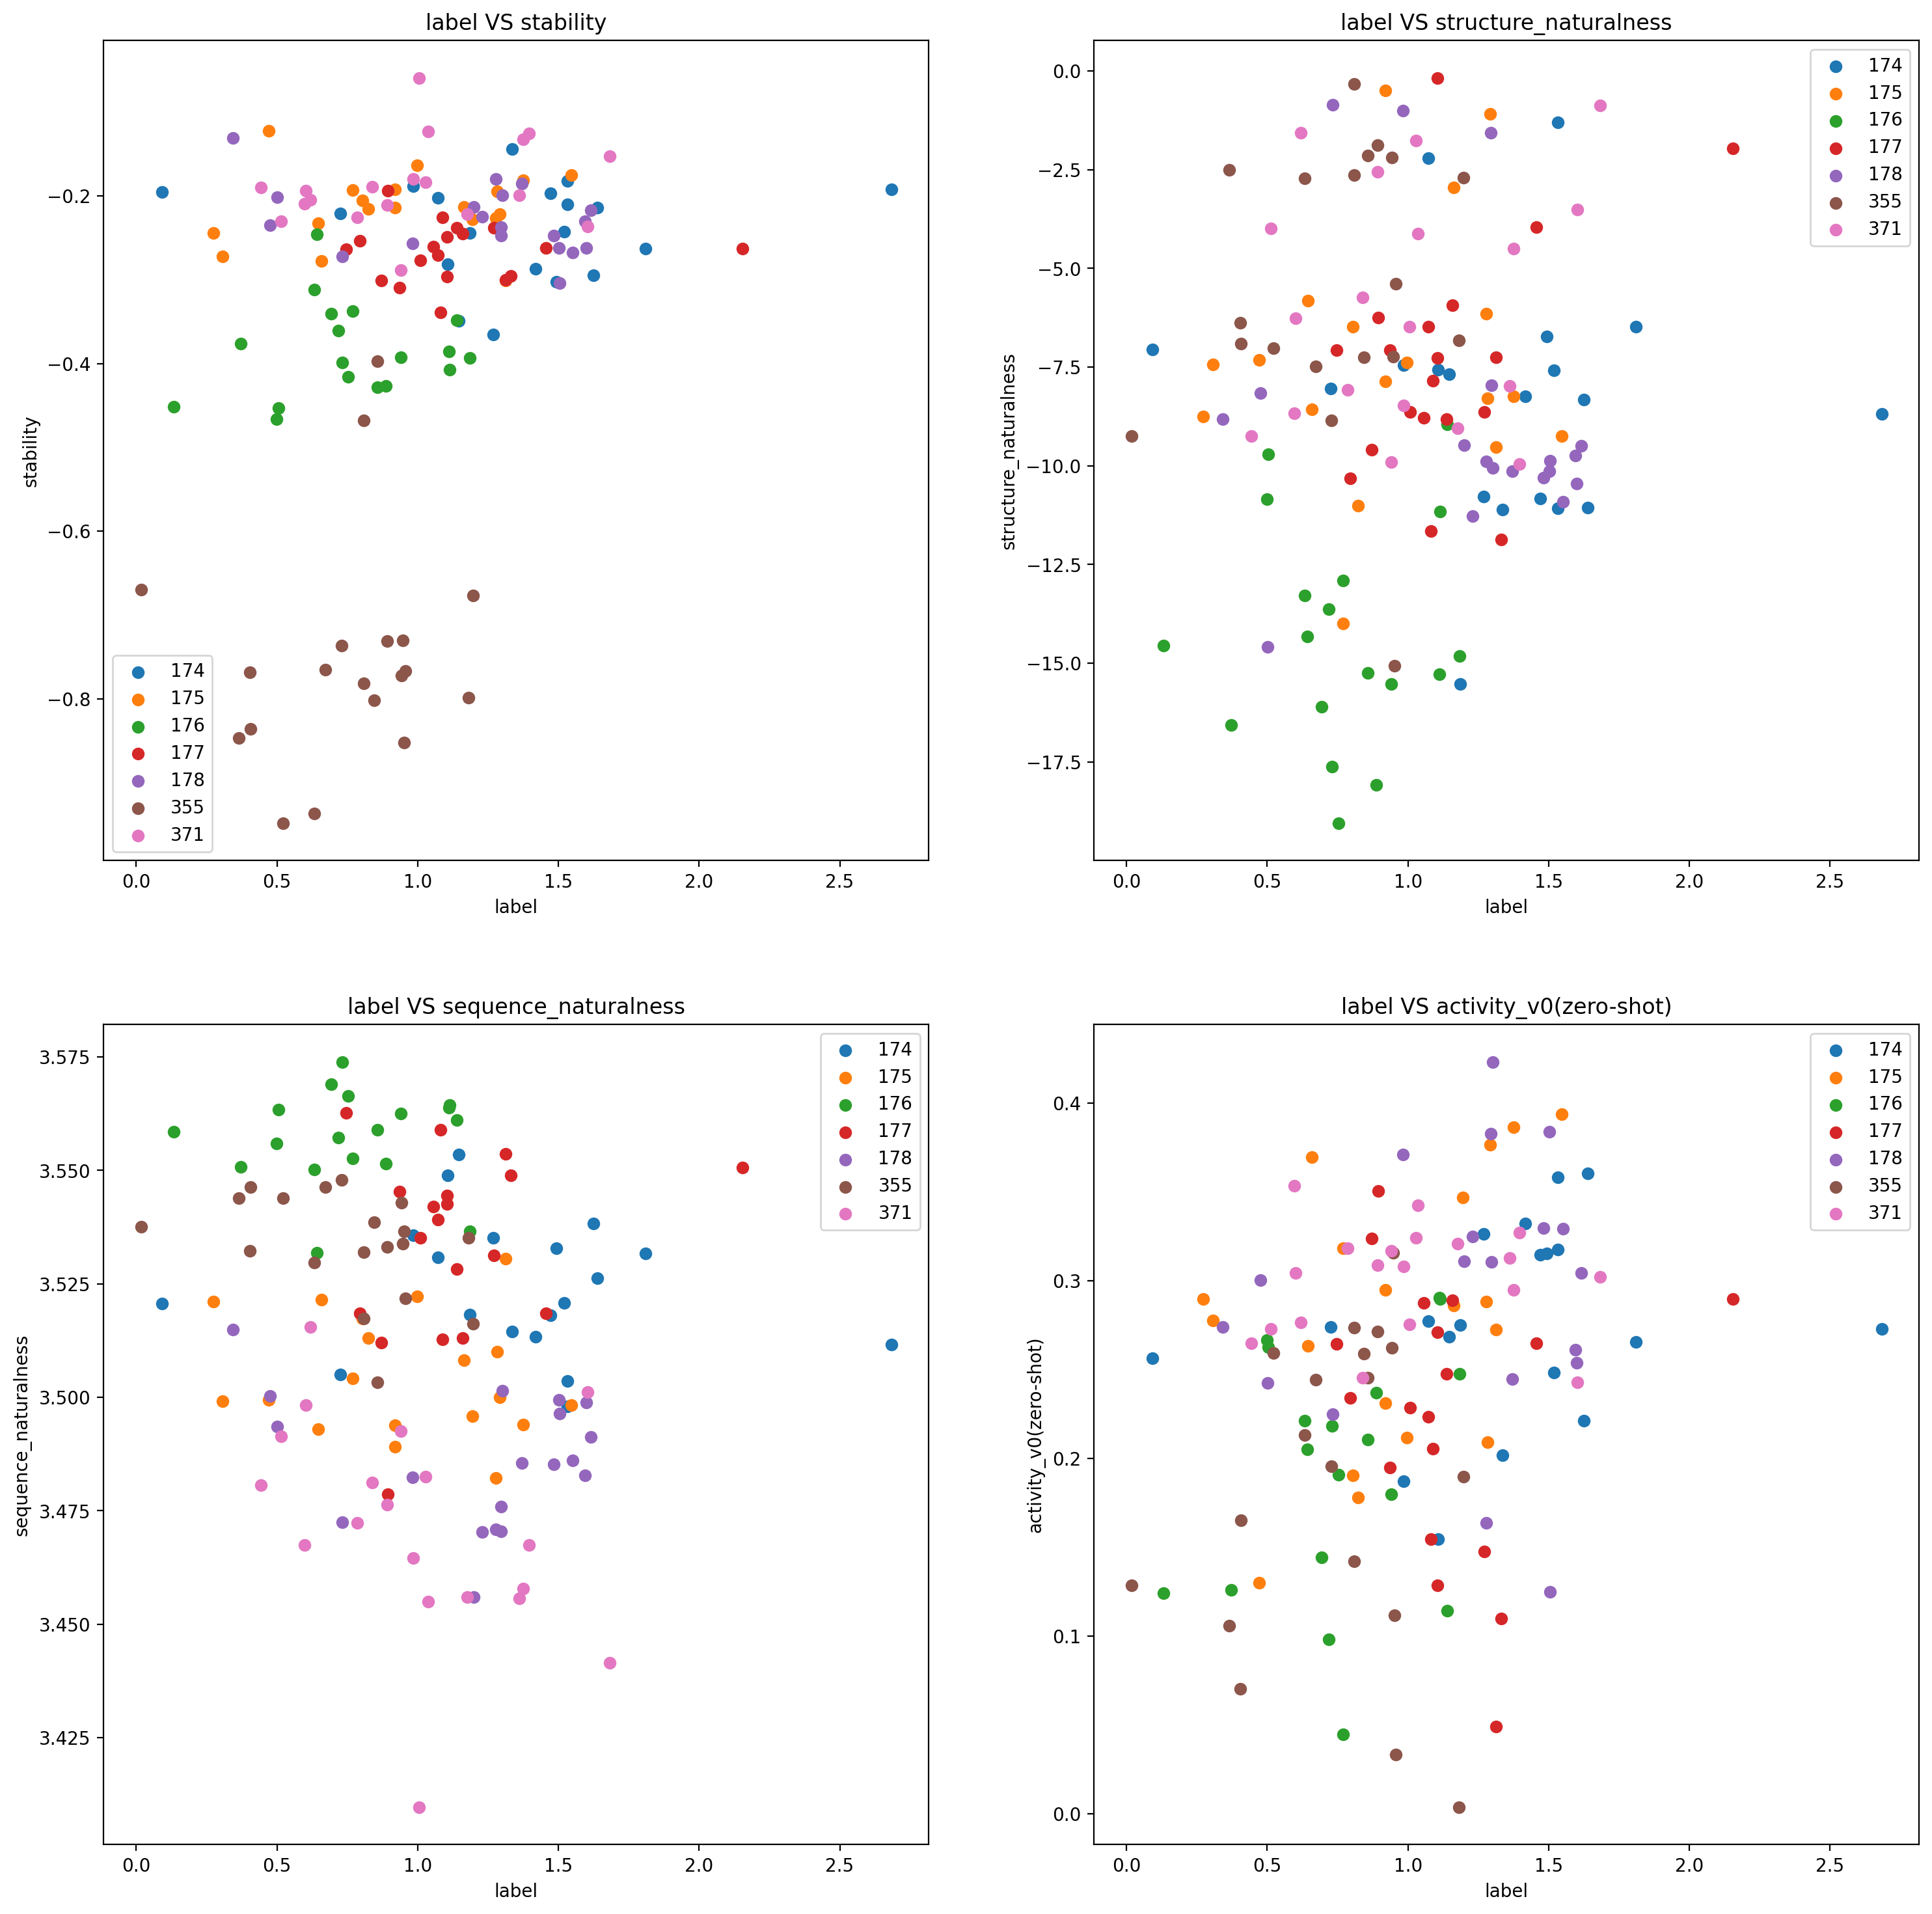

In [63]:
def scatter_two_score(data, s1, s2):
    posis = data['mut1'].drop_duplicates().to_list()
    sp = scipy.stats.spearmanr(data[s1], data[s2])
    for posi in posis:
        plt.scatter(data[(data['mut1']==posi)][s1], 
                data[(data['mut1']==posi)][s2]
               )
    plt.legend(posis)
    plt.xlabel(f'{s1}')
    plt.ylabel(f'{s2}')
    plt.title(f'{s1} VS {s2}')

count = [1,2,3,4]
plt.figure(figsize=[18, 18], dpi=200)
for c, k in zip(count,['stability', 'structure_naturalness',
       'sequence_naturalness', 'activity_v0(zero-shot)']):
    plt.subplot(2, 2, c)
    scatter_two_score(data[(data['mut_num']==1)*(~data['label'].isnull())],
                               'label', k)
    #count += 1
plt.show()

## filter performance

In [68]:
def get_bicls_performance(k, data, reverse=True):
    percentiles = [5 * i for i in range(1, 12)]
    quantiles = [data.sort_values(by=k, ascending=reverse)[k].iloc[-p] for p in percentiles]
    # print(quantiles)
    if reverse: 
        # quantiles = quantiles[::-1]
        preds = [(data[k] < t) * 1 for t in quantiles]
    else:
        # quantiles = quantiles[::-1]
        preds = [(data[k] > t) * 1 for t in quantiles]
    label = (data['label'] > 1) * 1
    
    # 过滤后保留活性比wt好的比例
    metrics = {p: ((pred == 1) * (label == 1)).sum() / (label == 1).sum() 
               for pred, p in zip(preds, percentiles)}
    # print(k, quantiles, [((pred == 0) * (label == 0)).sum() for pred, p in zip(preds, percentiles)], 
    #       [(pred == 0).sum() for pred, p in zip(preds, percentiles)])
    return metrics

count = [1,2,3,4,5]
reverse = [True, False, False, False, False]
out = {}
for c, k, r in zip(count,['stability', 'structure_naturalness',
       'sequence_naturalness', 'activity_v0(zero-shot)'],
                  reverse):
    out[k] = get_bicls_performance(k, data[(~data['label'].isnull())], reverse=r)
pd.DataFrame(out)


,stability,structure_naturalness,sequence_naturalness,activity_v0(zero-shot)
5,0.955224,0.985075,0.925373,0.970149
10,0.895522,0.955224,0.880597,0.940299
15,0.835821,0.940299,0.835821,0.910448
20,0.820896,0.925373,0.820896,0.880597
25,0.791045,0.850746,0.761194,0.850746
30,0.746269,0.805970,0.716418,0.835821
35,0.716418,0.746269,0.701493,0.791045
40,0.671642,0.686567,0.641791,0.776119
45,0.626866,0.641791,0.597015,0.746269
50,0.567164,0.597015,0.552239,0.731343
